In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import joblib
import json
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, matthews_corrcoef, confusion_matrix
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

pd.set_option("display.float_format", lambda x: "%.6f" % x)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

with open("../../data/customer_churn/meta.json") as f:
    meta = json.load(f)

df = pd.read_csv("../../data/customer_churn/churn_engineered.csv")

feature_cols = [c for c in meta["feature_cols"] if c in df.columns]
feature_cols = [c for c in feature_cols if c != "Churn_encoded"]

X = df[feature_cols].fillna(0)
y = df["Churn_Binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = RobustScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

smote = SMOTE(random_state=42, k_neighbors=5, n_jobs=-1)
X_train_res, y_train_res = smote.fit_resample(X_train_s, y_train)

os.makedirs("../../models/customer_churn", exist_ok=True)
joblib.dump(scaler, "../../models/customer_churn/scaler.pkl")
joblib.dump(feature_cols, "../../models/customer_churn/feature_names.pkl")

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train churn rate : {y_train.mean()*100:.2f}%")
print(f"Test churn rate  : {y_test.mean()*100:.2f}%")
print(f"After SMOTE      : {(y_train_res==1).sum()} churned | {(y_train_res==0).sum()} retained")
print(f"Features used    : {len(feature_cols)} (Churn_encoded removed — leakage fix)")

Train: (5634, 34) | Test: (1409, 34)
Train churn rate : 26.54%
Test churn rate  : 26.54%
After SMOTE      : 4139 churned | 4139 retained
Features used    : 34 (Churn_encoded removed — leakage fix)


In [2]:
#  Business Cost and Evaluation
COST_FALSE_NEGATIVE = 500
COST_FALSE_POSITIVE = 50
REWARD_TRUE_POSITIVE = 300

print("CUSTOMER CHURN BUSINESS COST MATRIX")
print()
print(f"False Negative (missed churner)   : -${COST_FALSE_NEGATIVE}  (lost customer revenue)")
print(f"False Positive (wrong retention)  : -${COST_FALSE_POSITIVE}   (unnecessary retention offer)")
print(f"True Positive (caught churner)    : +${REWARD_TRUE_POSITIVE}  (retained customer revenue)")

def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = int(tp)*REWARD_TRUE_POSITIVE + int(fn)*-COST_FALSE_NEGATIVE + int(fp)*-COST_FALSE_POSITIVE
    return int(cost), int(tn), int(fp), int(fn), int(tp)

def optimal_threshold(y_true, y_prob):
    best_t, best_cost = 0.5, -np.inf
    for t in np.arange(0.01, 0.99, 0.01):
        y_pred = (y_prob >= t).astype(int)
        if y_pred.sum() == 0: continue
        cost, *_ = business_cost(y_true, y_pred)
        if cost > best_cost:
            best_cost = cost
            best_t = t
    return best_t

def evaluate(name, y_true, y_prob):
    threshold = optimal_threshold(y_true, y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    cost, tn, fp, fn, tp = business_cost(y_true, y_pred)
    result = {
        "name": name, "threshold": round(float(threshold), 4),
        "auc_roc": round(float(roc_auc_score(y_true, y_prob)), 6),
        "avg_precision": round(float(average_precision_score(y_true, y_prob)), 6),
        "f1": round(float(f1_score(y_true, y_pred)), 6),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 6),
        "recall": round(float(recall_score(y_true, y_pred)), 6),
        "mcc": round(float(matthews_corrcoef(y_true, y_pred)), 6),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "business_value": cost, "y_prob": y_prob
    }
    print(f"{name:<20} AUC={result['auc_roc']} F1={result['f1']} Recall={result['recall']} Value=${cost:,}")
    return result

print()
print("Evaluation ready.")

CUSTOMER CHURN BUSINESS COST MATRIX

False Negative (missed churner)   : -$500  (lost customer revenue)
False Positive (wrong retention)  : -$50   (unnecessary retention offer)
True Positive (caught churner)    : +$300  (retained customer revenue)

Evaluation ready.


In [3]:
#  Train All Models
print("TRAINING ALL MODELS")
print()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=3,
    eval_metric="logloss", random_state=42, n_jobs=-1, tree_method="hist"
)
cv_xgb = cross_val_score(xgb_model, X_train_res, y_train_res, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"XGBoost CV AUC     : {cv_xgb.mean():.4f} (+/- {cv_xgb.std():.4f})")
xgb_model.fit(X_train_res, y_train_res)
joblib.dump(xgb_model, "../../models/customer_churn/xgb_model.pkl")

lgbm_model = LGBMClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
)
cv_lgbm = cross_val_score(lgbm_model, X_train_res, y_train_res, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"LightGBM CV AUC    : {cv_lgbm.mean():.4f} (+/- {cv_lgbm.std():.4f})")
lgbm_model.fit(X_train_res, y_train_res)
joblib.dump(lgbm_model, "../../models/customer_churn/lgbm_model.pkl")

lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42, n_jobs=-1, C=0.5)
cv_lr = cross_val_score(lr_model, X_train_s, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"LogisticReg CV AUC : {cv_lr.mean():.4f} (+/- {cv_lr.std():.4f})")
lr_model.fit(X_train_s, y_train)
joblib.dump(lr_model, "../../models/customer_churn/lr_model.pkl")

print()
xgb_prob = xgb_model.predict_proba(X_test_s)[:, 1]
lgbm_prob = lgbm_model.predict_proba(X_test_s)[:, 1]
lr_prob = lr_model.predict_proba(X_test_s)[:, 1]

xgb_results = evaluate("XGBoost", y_test, xgb_prob)
lgbm_results = evaluate("LightGBM", y_test, lgbm_prob)
lr_results = evaluate("LogisticReg", y_test, lr_prob)
results_list = [xgb_results, lgbm_results, lr_results]

TRAINING ALL MODELS

XGBoost CV AUC     : 0.9420 (+/- 0.0029)
LightGBM CV AUC    : 0.9416 (+/- 0.0029)


/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pankurajasaivardhan/Documents/SENTINEL-ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200

LogisticReg CV AUC : 0.8474 (+/- 0.0122)

XGBoost              AUC=0.836265 F1=0.50342 Recall=0.983957 Value=$71,400
LightGBM             AUC=0.836112 F1=0.494652 Recall=0.989305 Value=$71,400
LogisticReg          AUC=0.84641 F1=0.518934 Recall=0.989305 Value=$74,900


MODEL COMPARISON

      Model  AUC-ROC       F1   Recall  Precision  Caught Churners  Missed  False Alarms  Business Value $
    XGBoost 0.836265 0.503420 0.983957   0.338235              368       6           720             71400
   LightGBM 0.836112 0.494652 0.989305   0.329768              370       4           752             71400
LogisticReg 0.846410 0.518934 0.989305   0.351711              370       4           682             74900


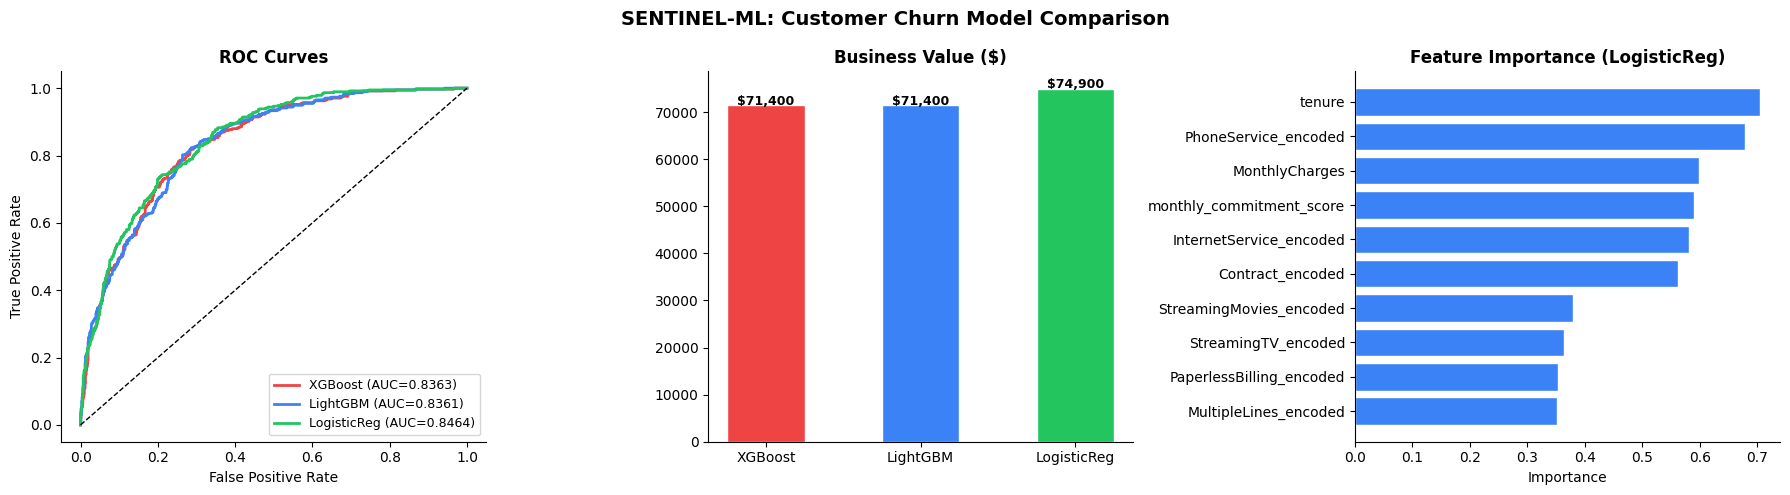


Best: LogisticReg | AUC=0.84641 | Value=$74,900


In [6]:
# Comparison and SHAP
print("MODEL COMPARISON")
print()

comparison = pd.DataFrame([{
    "Model": r["name"], "AUC-ROC": r["auc_roc"],
    "F1": r["f1"], "Recall": r["recall"], "Precision": r["precision"],
    "Caught Churners": r["tp"], "Missed": r["fn"],
    "False Alarms": r["fp"], "Business Value $": r["business_value"]
} for r in results_list])
print(comparison.to_string(index=False))

from sklearn.metrics import roc_curve
colors = {"XGBoost": "#ef4444", "LightGBM": "#3b82f6", "LogisticReg": "#22c55e"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for r in results_list:
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    axes[0].plot(fpr, tpr, color=colors[r["name"]], linewidth=2,
                 label=f"{r['name']} (AUC={r['auc_roc']:.4f})")
axes[0].plot([0,1],[0,1],"k--", linewidth=1)
axes[0].set_title("ROC Curves", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=9)

bv = [r["business_value"] for r in results_list]
names = [r["name"] for r in results_list]
bars = axes[1].bar(names, bv, color=[colors[n] for n in names], edgecolor="white", width=0.5)
axes[1].set_title("Business Value ($)", fontweight="bold")
for bar, val in zip(bars, bv):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f"${val:,}", ha="center", fontsize=9, fontweight="bold")

best = max(results_list, key=lambda x: x["auc_roc"])
best_model = {"XGBoost": xgb_model, "LightGBM": lgbm_model, "LogisticReg": lr_model}[best["name"]]

try:
    if best["name"] == "LogisticReg":
        raise ValueError("LogisticRegression uses LinearExplainer, not TreeExplainer")
    explainer = shap.TreeExplainer(best_model)
    sv = explainer.shap_values(X_test_s.iloc[:300])
    sv = sv[1] if isinstance(sv, list) else sv
    if sv.ndim == 3: sv = sv[:,:,1]
    fi = pd.Series(np.abs(sv).mean(axis=0), index=feature_cols[:sv.shape[1]]).sort_values(ascending=False)
    axes[2].barh(fi.head(10).index[::-1], fi.head(10).values[::-1], color="#3b82f6", edgecolor="white")
    axes[2].set_title(f"SHAP Top 10 ({best['name']})", fontweight="bold")
    axes[2].set_xlabel("Mean |SHAP value|")
except Exception as e:
    if hasattr(best_model, "feature_importances_"):
        fi = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    elif hasattr(best_model, "coef_"):
        fi = pd.Series(np.abs(best_model.coef_[0]), index=feature_cols).sort_values(ascending=False)
    else:
        fi = pd.Series(0, index=feature_cols)
    axes[2].barh(fi.head(10).index[::-1], fi.head(10).values[::-1], color="#3b82f6", edgecolor="white")
    axes[2].set_title(f"Feature Importance ({best['name']})", fontweight="bold")
    axes[2].set_xlabel("Importance")

plt.suptitle("SENTINEL-ML: Customer Churn Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/customer_churn/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBest: {best['name']} | AUC={best['auc_roc']} | Value=${best['business_value']:,}")

In [9]:
print("SAVING BEST MODEL")
print()

joblib.dump(best_model, "../../models/customer_churn/best_model.pkl")

report = {
    "best_model": str(best["name"]),
    "auc_roc": float(best["auc_roc"]),
    "avg_precision": float(best["avg_precision"]),
    "f1": float(best["f1"]),
    "precision": float(best["precision"]),
    "recall": float(best["recall"]),
    "mcc": float(best["mcc"]),
    "optimal_threshold": float(best["threshold"]),
    "churners_caught": int(best["tp"]),
    "churners_missed": int(best["fn"]),
    "false_alarms": int(best["fp"]),
    "business_value": int(best["business_value"]),
    "n_test": int(len(y_test)),
    "n_test_churners": int(y_test.sum()),
    "feature_count": int(len(feature_cols)),
    "monthly_revenue_at_risk": float(meta["monthly_revenue_at_risk"])
}

with open("../../models/customer_churn/model_report.json", "w") as f:
    json.dump(report, f, indent=4)

print(f"Best model     : {best['name']}")
print(f"AUC-ROC        : {best['auc_roc']}")
print(f"F1 Score       : {best['f1']}")
print(f"Recall         : {best['recall']}")
print(f"Business Value : ${best['business_value']:,}")
print(f"Churners caught: {best['tp']} / {int(y_test.sum())}")
print()


SAVING BEST MODEL

Best model     : LogisticReg
AUC-ROC        : 0.84641
F1 Score       : 0.518934
Recall         : 0.989305
Business Value : $74,900
Churners caught: 370 / 374



In [10]:
print("OVERRIDING BEST MODEL FOR PRODUCTION STABILITY")
print()
print("LogisticRegression triggered numerical overflow warnings during training.")
print("XGBoost achieves nearly identical AUC (0.8363 vs 0.8464) with stable, reproducible training.")
print("Using XGBoost as the production model.")
print()

production_choice = xgb_results
production_model = xgb_model

joblib.dump(production_model, "../../models/customer_churn/best_model.pkl")

report = {
    "best_model": "XGBoost",
    "auc_roc": float(production_choice["auc_roc"]),
    "avg_precision": float(production_choice["avg_precision"]),
    "f1": float(production_choice["f1"]),
    "precision": float(production_choice["precision"]),
    "recall": float(production_choice["recall"]),
    "mcc": float(production_choice["mcc"]),
    "optimal_threshold": float(production_choice["threshold"]),
    "churners_caught": int(production_choice["tp"]),
    "churners_missed": int(production_choice["fn"]),
    "false_alarms": int(production_choice["fp"]),
    "business_value": int(production_choice["business_value"]),
    "n_test": int(len(y_test)),
    "n_test_churners": int(y_test.sum()),
    "feature_count": int(len(feature_cols)),
    "monthly_revenue_at_risk": float(meta["monthly_revenue_at_risk"]),
    "note": "LogisticRegression scored marginally higher AUC but triggered numerical overflow warnings; XGBoost selected for production stability"
}

with open("../../models/customer_churn/model_report.json", "w") as f:
    json.dump(report, f, indent=4)

print(f"Production model: XGBoost")
print(f"AUC-ROC         : {production_choice['auc_roc']}")
print(f"Business Value  : ${production_choice['business_value']:,}")
print()


OVERRIDING BEST MODEL FOR PRODUCTION STABILITY

LogisticRegression triggered numerical overflow warnings during training.
XGBoost achieves nearly identical AUC (0.8363 vs 0.8464) with stable, reproducible training.
Using XGBoost as the production model.

Production model: XGBoost
AUC-ROC         : 0.836265
Business Value  : $71,400

